In [116]:
import numpy as np
import matplotlib.pyplot as plt


dvdt = dvdt = v[i] * (a - v[i]) * (v[i] - 1) - w[i] + I_ext

dwdt =  b* v[i] - r * w[i]

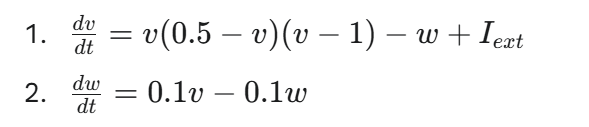

In [117]:
# default simulation parameters

a = 0.5  # 
b = 0.1  # 
r = 0.1  # 
dt = 1e-3
T = 300


#  Model Simultion Function

In [118]:

# --- FHN Model Simulation Function ---

def fhn_euler(v0, w0, I_ext, a, b, r, dt, T):
    """
    Simulates the FitzHugh-Nagumo model using Euler's method.

    Args:
        v0 (float): Initial membrane potential.
        w0 (float): Initial recovery variable.
        I_ext (float): External stimulus current.
        a, b, r (float): Model parameters.
        dt (float): Time step for the simulation.
        T (float): Total simulation time.

    Returns:
        tuple: A tuple containing time, V, and W arrays.
    """
    # Create time array
    t = np.arange(0, T, dt)
    # Initialize V and W arrays as zeros of the same length as t
    v = np.zeros_like(t)
    w = np.zeros_like(t)
    # Set initial conditions
    v[0] = v0
    w[0] = w0

    # Euler method implementation
    for i in range(len(t) - 1):
        # dv/dt = v(a-v)(v-1) - w + I_ext
        dvdt = v[i] * (a - v[i]) * (v[i] - 1) - w[i] + I_ext
        # dw/dt = b*v - r*w (Corrected equation)
        dwdt = b * v[i] - r * w[i]
        
        v[i+1] = v[i] + dt * dvdt
        w[i+1] = w[i] + dt * dwdt
        
    return t, v, w



# Helper Plotting Functions

In [119]:
# ...existing code...
def plot_phase_plane(ax, a, b, r, I_ext,  xlim = (-1.5, 1.5), ylim = (-1.5, 1.5), mark_fixed_points=True):
    """Plots the nullclines and vector field on a given axis and marks their intersections (fixed points)."""
    # Define the grid for the vector field
    v_range = np.linspace(xlim[0], xlim[1], 50)
    w_range = np.linspace(ylim[0], ylim[1], 50)
    V_grid, W_grid = np.meshgrid(v_range, w_range)

    # Calculate the derivatives at each grid point
    dVdt = V_grid * (a - V_grid) * (V_grid - 1) - W_grid + I_ext
    dWdt = b * V_grid - r * W_grid

    # Plot the vector field (scale chosen to make arrows readable)
    ax.quiver(V_grid, W_grid, dVdt, dWdt, color='gray', alpha=0.6, scale=50)

    # Plot the nullclines
    v_nullcline_v = np.linspace(xlim[0], xlim[1], 400)
    # v-nullcline: dv/dt = 0 => w = v(a-v)(v-1) + I_ext
    v_nullcline_w = v_nullcline_v * (a - v_nullcline_v) * (v_nullcline_v - 1) + I_ext
    # w-nullcline: dw/dt = 0 => w = (b/r)*v
    w_nullcline_w = (b / r) * v_nullcline_v

    ax.plot(v_nullcline_v, v_nullcline_w, 'b-', label='v-nullcline (dv/dt=0)')
    ax.plot(v_nullcline_v, w_nullcline_w, 'r-', label='w-nullcline (dw/dt=0)')

    # Find intersections (fixed points) by solving the cubic:
    # -v^3 + (1+a)v^2 - (a + b/r)v + I_ext = 0
    coeffs = [-1.0, 1.0 + a, -(a + (b / r)), I_ext]
    roots = np.roots(coeffs)
    # keep real roots (allow tiny imag parts)
    real_roots = np.real(roots[np.isclose(np.imag(roots), 0.0, atol=1e-8)])

    fixed_points = []
    if mark_fixed_points and real_roots.size > 0:
        for idx, v_fp in enumerate(np.sort(real_roots)):
            w_fp = (b / r) * v_fp  # can also use v-nullcline formula (should be same)
            # Linearize to determine stability
            df_dv = -3.0 * v_fp**2 + 2.0 * (1.0 + a) * v_fp - a
            jacobian = np.array([[df_dv, -1.0],
                                 [b,     -r]])
            eigvals = np.linalg.eigvals(jacobian)
            stable = np.all(np.real(eigvals) < 0)
            color = 'g' if stable else 'r'
            marker = 'o' if stable else 's'

            ax.plot(v_fp, w_fp, marker=marker, color=color, markersize=8, zorder=5)
            ax.annotate(f'FP{idx+1}\n(v={v_fp:.3f}, w={w_fp:.3f})',
                        xy=(v_fp, w_fp),
                        xytext=(6, 6 + 6*idx),
                        textcoords='offset points',
                        fontsize=8,
                        color=color,
                        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))
            fixed_points.append((v_fp, w_fp, stable, eigvals))

    ax.set_xlabel('Membrane Potential (V)')
    ax.set_ylabel('Recovery Variable (W)')
    ax.set_title(f'Phase Plane (I_ext = {I_ext})')
    ax.legend()
    ax.grid(True)
    ax.set_xlim([xlim[0], xlim[1]])
    ax.set_ylim([ylim[0], ylim[1]])

    return fixed_points
# ...existing code...

In [ ]:
def plot_time_series(ax, t, v, w, title):
    """Plots the V(t) and W(t) time series on a given axis."""
    ax.plot(t, v, label='V(t)')
    ax.plot(t, w, label='W(t)')
    ax.set_xlabel('Time (t)')
    ax.set_ylabel('State Variables')
    ax.set_title(title)
    ax.legend()
    ax.grid(True)


#  Case 1


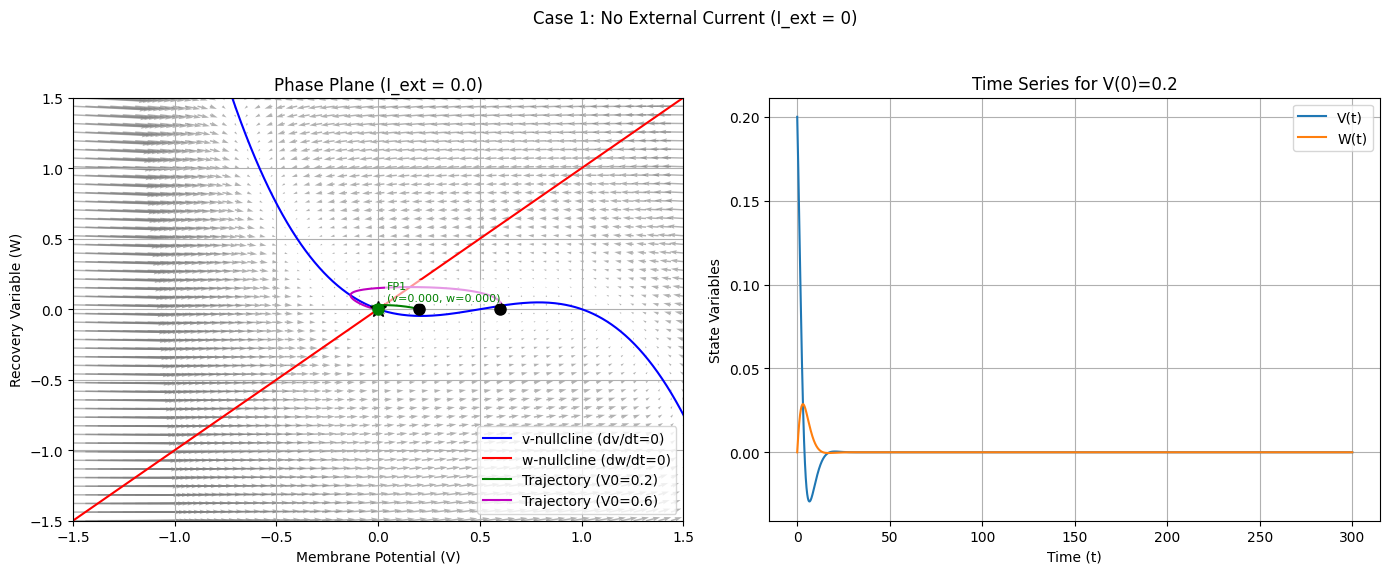

In [121]:
# --- Case 1: I_ext = 0 ---
I_ext_1 = 0.0 # No external current

# Initial conditions | a = 0.5

# i. V(0) < a and W(0) = 0
v0_1i, w0_1i = 0.2, 0.0 #  Voltage like variable (proxy for voltage), Recovery like variable 

# ii. V(0) > a and W(0) = 0
v0_1ii, w0_1ii = 0.6, 0.0 # 

# Run simulations
t1i, v1i, w1i = fhn_euler(v0_1i, w0_1i, I_ext_1, a, b, r, dt, T) 
t1ii, v1ii, w1ii = fhn_euler(v0_1ii, w0_1ii, I_ext_1, a, b, r, dt, T)

# Plotting
fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(14, 6))
# a. Phase plot
plot_phase_plane(ax1a, a, b, r, I_ext_1)
ax1a.plot(v1i, w1i, 'g-', label=f'Trajectory (V0={v0_1i})')
ax1a.plot(v1ii, w1ii, 'm-', label=f'Trajectory (V0={v0_1ii})')
ax1a.plot([v0_1i, v0_1ii], [w0_1i, w0_1ii], 'ko', markersize=8) # Start points
ax1a.plot(0, 0, 'k*', markersize=12) # End point (Fixed Point)
ax1a.legend()

# b. Time series plots
plot_time_series(ax1b, t1i, v1i, w1i, f'Time Series for V(0)={v0_1i}')
plt.suptitle("Case 1: No External Current (I_ext = 0)")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Find Oscilatory Regime
>> both numerical and theoretical approaches


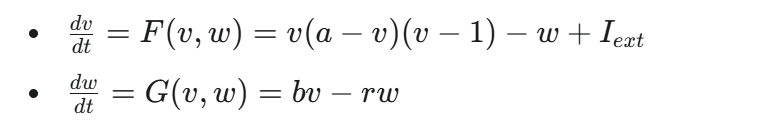

Calculated jacobian:
\begin{bmatrix}
df/dv & df/dw \\
dg/dv & dg/dw \\
\end{bmatrix}


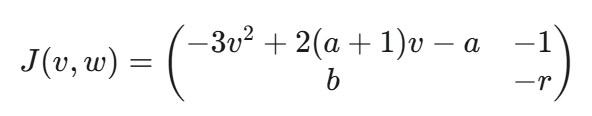

Equation all fixed points must satisfy, i.e. F, G = 0:

$-v^3 + (1+a)v^2 - (a + b/r)v + I_ext = 0$


In [122]:

def find_fhn_bifurcations_grid_search(a, b, r, i_min=0.0, i_max=1.0, num_steps=500):
    """
    Performs a grid search to find the Hopf bifurcation points (I1, I2)
    for the FitzHugh-Nagumo model.
    """
    
    # 1. Set up the grid for I_ext
    i_ext_range = np.linspace(i_min, i_max, num_steps)
    max_real_parts = [] # To store the max real part of the eigenvalues

    # 2. Iterate through each I_ext value
    for i_ext in i_ext_range:
        # Find the fixed point(s) by finding the roots of the cubic equation:

        coeffs = [-1, 1 + a, -(a + b / r), i_ext]
        roots = np.roots(coeffs)
        
        # We are interested in the real-valued fixed point
        # For these parameters, there is only one real root in the oscillatory range
        v_fp = np.real(roots[np.isreal(roots)])[0]

        
        df_dv = -3*v_fp**2 + 2*(1+a)*v_fp - a
        
        jacobian = np.array([[df_dv, -1], 
                             [b,     -r]])
        
        # 4. Find the eigenvalues and store the maximum real part
        eigenvalues = np.linalg.eigvals(jacobian)
        max_real_parts.append(np.max(np.real(eigenvalues)))

    # 5. Find where the sign of the max real part changes
    max_real_parts = np.array(max_real_parts)
    # Find indices where the sign changes from negative to positive (I1)
    # or positive to negative (I2)
    sign_changes = np.where(np.diff(np.sign(max_real_parts)))[0]
    
    if len(sign_changes) < 2:
        print("Could not find two bifurcation points in the given range.")
        return None, None, i_ext_range, max_real_parts
        
    i1_index = sign_changes[0]
    i2_index = sign_changes[1]
    
    I1 = i_ext_range[i1_index]
    I2 = i_ext_range[i2_index]
    
    return I1, I2, i_ext_range, max_real_parts


--- Numerical Grid Search Results ---
Oscillatory behavior begins around I1 ≈ 0.3206
Oscillatory behavior ends around I2 ≈ 0.6774


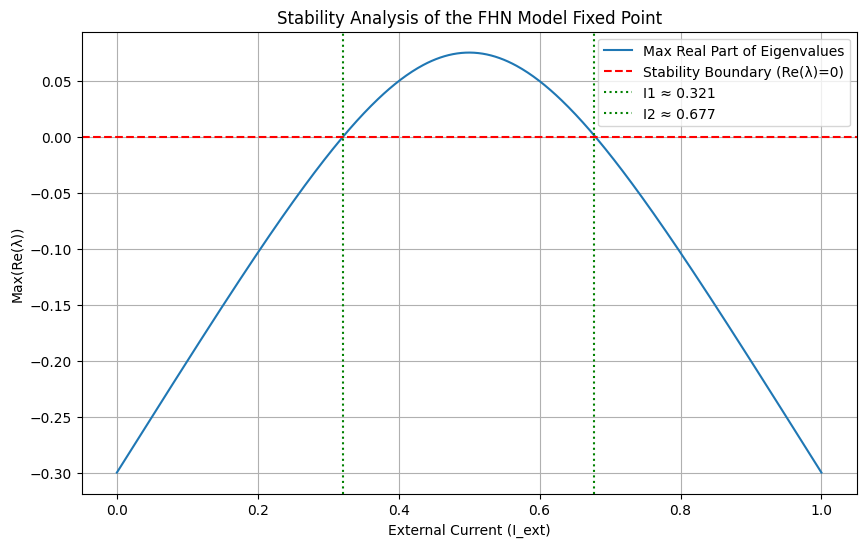

In [123]:
# run the grid Search 


I1_num, I2_num, i_range, real_parts = find_fhn_bifurcations_grid_search(a, b, r)

print(f"--- Numerical Grid Search Results ---")
print(f"Oscillatory behavior begins around I1 ≈ {I1_num:.4f}")
print(f"Oscillatory behavior ends around I2 ≈ {I2_num:.4f}")

# --- Plot the results ---
plt.figure(figsize=(10, 6))
plt.plot(i_range, real_parts, label='Max Real Part of Eigenvalues')
plt.axhline(0, color='r', linestyle='--', label='Stability Boundary (Re(λ)=0)')
plt.axvline(I1_num, color='g', linestyle=':', label=f'I1 ≈ {I1_num:.3f}')
plt.axvline(I2_num, color='g', linestyle=':', label=f'I2 ≈ {I2_num:.3f}')

plt.title('Stability Analysis of the FHN Model Fixed Point')
plt.xlabel('External Current (I_ext)')
plt.ylabel('Max(Re(λ))')
plt.legend()
plt.grid(True)
plt.show()

## Theoretical Verification

In [124]:
def calculate_fhn_bifurcations_analytical(a, b, r):
    """
    Calculates the exact Hopf bifurcation points (I1, I2) for the FHN model.
    """
    # The bifurcation occurs when the trace of the Jacobian is zero:
    # when trace is zero, no real part. Trace > 0 means unstable , Trace < 0 means stable
    # 3v^2 - 2(1+a)v + (a+r) = 0
    # We solve this quadratic equation for v.
    coeffs = [3, -2 * (1 + a), a + r]
    v_bifurcation_points = np.roots(coeffs)
    v1 = min(v_bifurcation_points)
    v2 = max(v_bifurcation_points)

    # Now, find the I_ext that corresponds to each v value using the
    # nullcline intersection equation: I_ext = (b/r)v - v(a-v)(v-1)
    def find_I(v, a, b, r):
        return (b / r) * v - (v * (a - v) * (v - 1))

    I1 = find_I(v1, a, b, r)
    I2 = find_I(v2, a, b, r)
    
    return I1, I2

# --- Run the Analytical Calculation ---
I1_ana, I2_ana = calculate_fhn_bifurcations_analytical(a, b, r)

print(f"--- Analytical Calculation Results ---")
print(f"The precise value for I1 is: {I1_ana:.6f}")
print(f"The precise value for I2 is: {I2_ana:.6f}")

--- Analytical Calculation Results ---
The precise value for I1 is: 0.321115
The precise value for I2 is: 0.678885


# Plot for Case 2

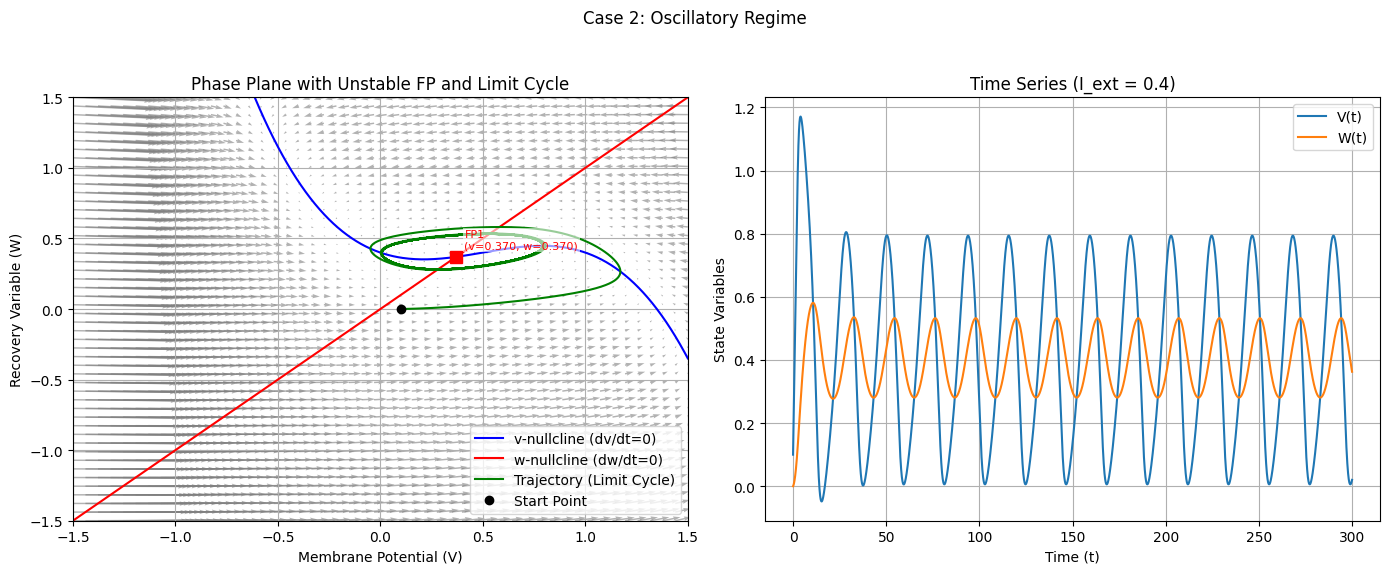

In [125]:
I_ext_2 = 0.4 # Sample value in acceptable range 
v0_2, w0_2 = 0.1, 0.0 # Perturbation near the fixed point

# Run simulation
t2, v2, w2 = fhn_euler(v0_2, w0_2, I_ext_2, a, b, r, dt, T)

# Plotting
fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(14, 6))
# a, b. Phase plot with unstable fixed point and limit cycle
plot_phase_plane(ax2a, a, b, r, I_ext_2)
ax2a.plot(v2, w2, 'g-', label='Trajectory (Limit Cycle)')
ax2a.plot(v0_2, w0_2, 'ko', markersize=6, label='Start Point')

ax2a.set_title('Phase Plane with Unstable FP and Limit Cycle')
ax2a.legend()
# c. Time series plot
plot_time_series(ax2b, t2, v2, w2, f'Time Series (I_ext = {I_ext_2})')
plt.suptitle("Case 2: Oscillatory Regime")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Plot for Case 3

Running Case 3...


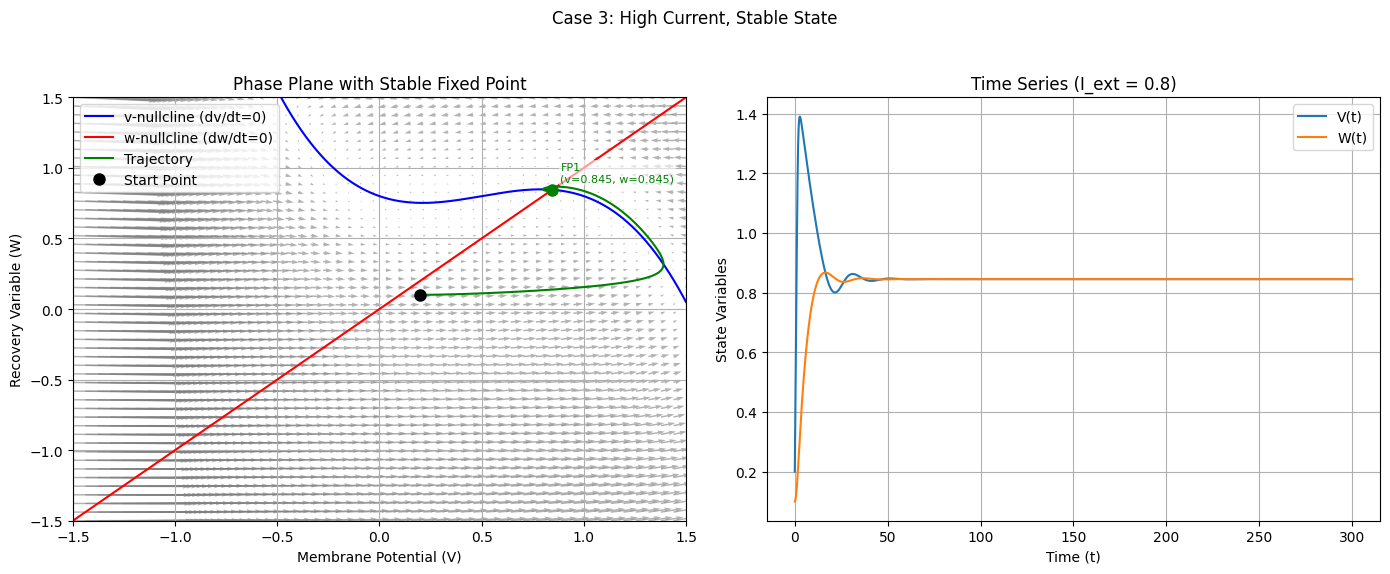

In [126]:

# --- Case 3: Stable High-Voltage State (I_ext > I2) ---
print("Running Case 3...")
I_ext_3 = 0.8 # Sample value > I2 
v0_3, w0_3 = 0.2, 0.1 # Perturbation

# Run simulation
t3, v3, w3 = fhn_euler(v0_3, w0_3, I_ext_3, a, b, r, dt, T)

# Plotting
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(14, 6))
# a, b. Phase plot showing stable fixed point
plot_phase_plane(ax3a, a, b, r, I_ext_3)
ax3a.plot(v3, w3, 'g-', label='Trajectory')
ax3a.plot(v0_3, w0_3, 'ko', markersize=8, label='Start Point')
ax3a.set_title('Phase Plane with Stable Fixed Point')
ax3a.legend()
# c. Time series plot
plot_time_series(ax3b, t3, v3, w3, f'Time Series (I_ext = {I_ext_3})')
plt.suptitle("Case 3: High Current, Stable State")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



# Analytic Solution to Find Values for Bi-stability
- Nullcline intersection: $I_{ext} = v^3 - (a+1)v^2 + (a + b/r)v$
- The cubic function on the right must have three roots. 



In [127]:

def find_bistability_conditions(a, br_ratio= None):
    """
    Calculates the analytical conditions for bistability in the FHN model.

    Args:
        a (float): The 'a' parameter of the FHN model.
        br_ratio (float, optional): A specific b/r ratio to analyze.
                                    If None, only the maximum ratio is returned.

    Returns:
        tuple: Depending on input, returns max b/r ratio and/or the
               I_ext range for a given b/r ratio.
    """
    # --- Part 1: Find the maximum b/r ratio for bistability to be possible ---

    # We need the derivative of P(v) to have two real roots.
    # P(v) = v^3 - (a+1)v^2 + (a + b/r)v
    # dP/dv = 3v^2 - 2(a+1)v + (a + b/r) = 0
    # The discriminant of this quadratic (B^2 - 4AC) must be > 0.
    # A=3, B=-2(a+1), C=(a + b/r)
    
    discriminant_term_A = (-2 * (a + 1))**2
    discriminant_term_B_coeff = -4 * 3 * a
    discriminant_term_C_coeff = -4 * 3

    # Discriminant: (4(a+1)^2 - 12a) - 12*(b/r) > 0
    # This means: 12*(b/r) < 4(a+1)^2 - 12a
    # (b/r) < (4(a+1)^2 - 12a) / 12 = ((a+1)^2 - 3a) / 3
    
    max_br_ratio = ((a + 1)**2 - 3*a) / 3

    if br_ratio is None:
        return max_br_ratio

    # --- Part 2: For a given b/r ratio, find the I_ext range ---
    
    if br_ratio >= max_br_ratio:
        print(f"Error: The provided b/r ratio ({br_ratio:.4f}) is too high.")
        print(f"It must be less than {max_br_ratio:.4f} for bistability.")
        return None, None
        
    # Solve dP/dv = 0 for the v-coordinates of the critical points
    coeffs = [3, -2 * (a + 1), (a + br_ratio)]
    v_crit = np.roots(coeffs)
    v_c1, v_c2 = np.sort(v_crit) # v_c1 is local max, v_c2 is local min

    # Define the polynomial P(v)
    def P(v, a, br):
        return v**3 - (a + 1)*v**2 + (a + br)*v

    # Calculate the values of I_ext at these critical points
    I_at_max = P(v_c1, a, br_ratio)
    I_at_min = P(v_c2, a, br_ratio)

    # The valid range for I_ext is between these two values
    I_ext_min = I_at_min
    I_ext_max = I_at_max
    
    return I_ext_min, I_ext_max, v_crit




In [128]:
# Use the same 'a' paramter
a = 0.5
b, r = 0.01, 0.1


# 1. Find the absolute maximum b/r ratio allowed
max_ratio = find_bistability_conditions(a)
print("--- Bistability Condition Analysis ---")
print(f"For a = {a}, bistability is only possible if b/r < {max_ratio:.4f}\n")

# In the code above, chose b=0.02 and r=0.1
current_br_ratio = b/r
print(f"The current ratio: b/r = {current_br_ratio:.4f} (which is < {max_ratio:.4f})")

I_min, I_max, v_points = find_bistability_conditions(a = a, br_ratio= current_br_ratio)

print(f"\nFor this ratio, bistability occurs when:")
print(f"  {I_min:.6f} < I_ext < {I_max:.6f}")




--- Bistability Condition Analysis ---
For a = 0.5, bistability is only possible if b/r < 0.2500

The current ratio: b/r = 0.1000 (which is < 0.2500)

For this ratio, bistability occurs when:
  0.027639 < I_ext < 0.072361


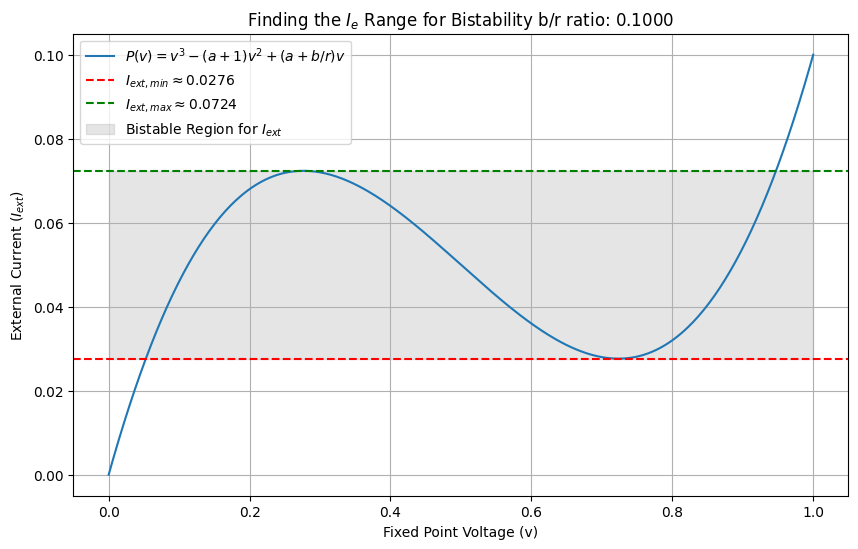

In [134]:
# --- Visualization of the Result ---
v_range = np.linspace(0, 1, 400)
I_values = v_range**3 - (a+1)*v_range**2 + (a + current_br_ratio)*v_range

plt.figure(figsize=(10, 6))
plt.plot(v_range, I_values, label='$P(v) = v^3 - (a+1)v^2 + (a+b/r)v$')
plt.axhline(I_min, color='r', linestyle='--', label=f'$I_{{ext, min}} \\approx {I_min:.4f}$')
plt.axhline(I_max, color='g', linestyle='--', label=f'$I_{{ext, max}} \\approx {I_max:.4f}$')

# Add a shaded region for bistability
plt.fill_between(v_range, I_min, I_max, color='gray', alpha=0.2, label='Bistable Region for $I_{ext}$')

plt.title(f'Finding the $I_e$ Range for Bistability b/r ratio: {current_br_ratio:.4f}')
plt.xlabel('Fixed Point Voltage (v)')
plt.ylabel('External Current ($I_{ext}$)')
plt.legend()
plt.grid(True)
plt.show()

In [130]:
(0.027 + 0.074)/2

0.050499999999999996

Running Case 4...


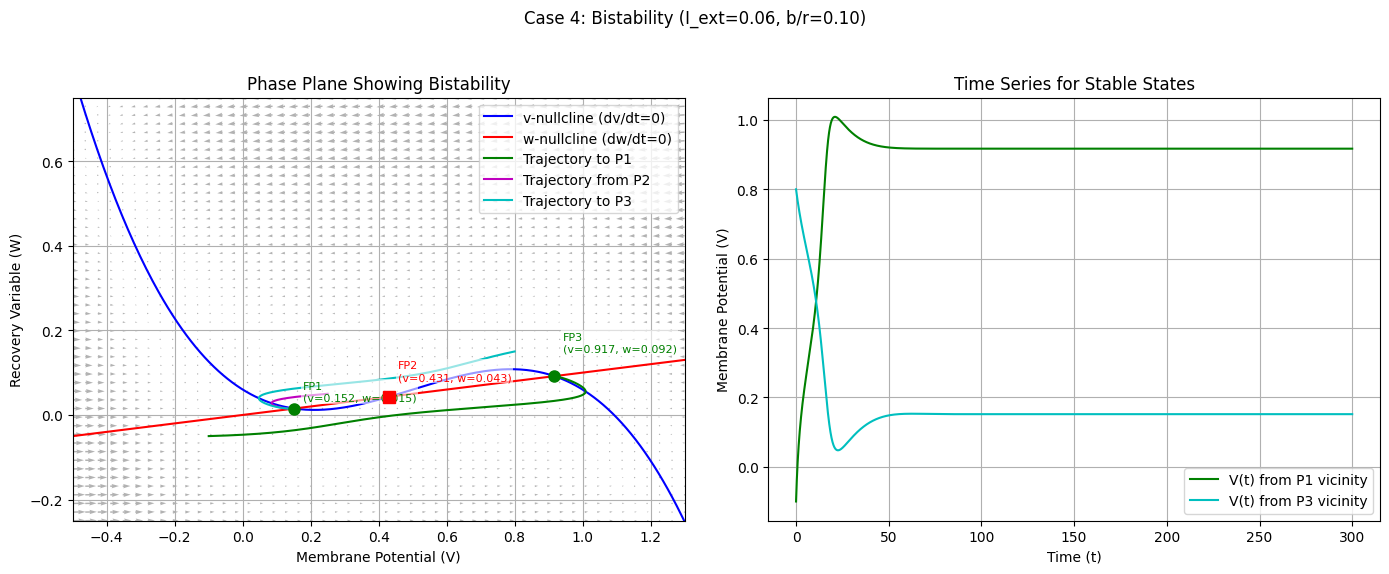

In [133]:
# --- Case 4: Bistability ---
print("Running Case 4...")
# New parameters to achieve bistability 
I_ext_4 = 0.06 # Midway in the bistable range
b_4 = 0.01
r_4 = 0.1 

# Initial conditions to show stability of different fixed points
v0_p1, w0_p1 = -0.1, -0.05 # Near P1 (stable)
v0_p2, w0_p2 = 0.25, 0.05  # Near P2 (unstable)
v0_p3, w0_p3 = 0.8, 0.15   # Near P3 (stable)

# Run simulations
t4_p1, v4_p1, w4_p1 = fhn_euler(v0_p1, w0_p1, I_ext_4, a, b_4, r_4, dt, T)
t4_p2, v4_p2, w4_p2 = fhn_euler(v0_p2, w0_p2, I_ext_4, a, b_4, r_4, dt, T)
t4_p3, v4_p3, w4_p3 = fhn_euler(v0_p3, w0_p3, I_ext_4, a, b_4, r_4, dt, T)

# Plotting
fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(14, 6))
# a, b. Phase plot showing bistability
plot_phase_plane(ax4a, a, b_4, r_4, I_ext_4, ylim= (-0.25, 0.75), xlim = (-0.5, 1.3))
ax4a.plot(v4_p1, w4_p1, 'g-', label='Trajectory to P1')
ax4a.plot(v4_p2, w4_p2, 'm-', label='Trajectory from P2')
ax4a.plot(v4_p3, w4_p3, 'c-', label='Trajectory to P3')
ax4a.set_title('Phase Plane Showing Bistability')
ax4a.legend()

# c. Time series plots
ax4b.plot(t4_p1, v4_p1, 'g-', label=f'V(t) from P1 vicinity')
ax4b.plot(t4_p3, v4_p3, 'c-', label=f'V(t) from P3 vicinity')
ax4b.set_xlabel('Time (t)')
ax4b.set_ylabel('Membrane Potential (V)')
ax4b.set_title('Time Series for Stable States')
ax4b.legend()
ax4b.grid(True)
plt.suptitle(f"Case 4: Bistability (I_ext={I_ext_4}, b/r={b_4/r_4:.2f})")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()